Using device: cuda
Epoch 50, Train Loss: -1.495758388859885, Val Loss: -2.0599731232779366
Epoch 100, Train Loss: 1.306665542636599, Val Loss: 0.2178781155858721
Epoch 150, Train Loss: 0.5766730606215341, Val Loss: -0.33802393971170697
Epoch 200, Train Loss: -0.7978159847259522, Val Loss: 4.293387319837298
Epoch 250, Train Loss: 0.3329428190588951, Val Loss: -0.9801198750904628
Epoch 300, Train Loss: -1.8185538291249956, Val Loss: -2.310766632080078
Epoch 350, Train Loss: 0.8560395492315293, Val Loss: -0.649357438496181
Epoch 400, Train Loss: -2.4662982665470667, Val Loss: -2.695801810673305
Epoch 450, Train Loss: -1.2883887603623527, Val Loss: -2.442453653063093
Epoch 500, Train Loss: -1.086894543664796, Val Loss: -2.8111240455082487


/tmp/ipykernel_19167/3149278085.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load(best_model_path, map_location=device))


Final samples shape: (200000, 6)
Final data_tensor shape: torch.Size([70000, 7])
Generated 200000 valid samples.


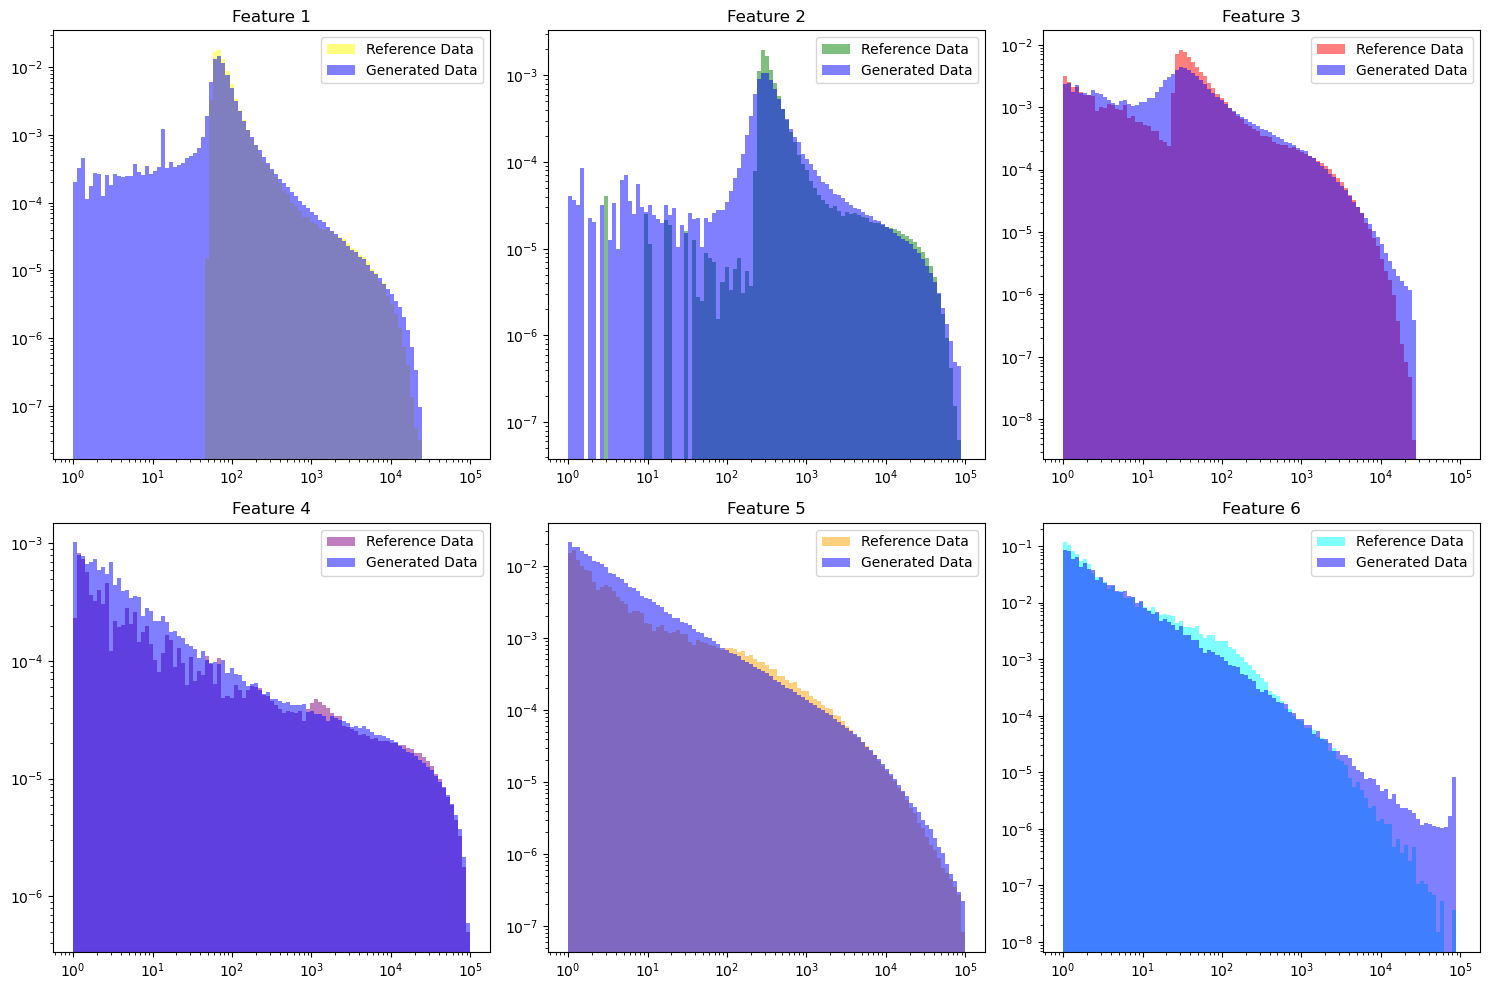

Final real data shape: (70000, 6)
Final gen shape: (70000, 6)
Epoch number 0/24
----------
train Loss: 0.6757 Acc: 0.5507
val Loss: 0.6678 Acc: 0.5691
Epoch number 1/24
----------
train Loss: 0.6691 Acc: 0.5671
val Loss: 0.6624 Acc: 0.5755
Epoch number 2/24
----------
train Loss: 0.6646 Acc: 0.5757
val Loss: 0.6590 Acc: 0.5837
Epoch number 3/24
----------
train Loss: 0.6626 Acc: 0.5795
val Loss: 0.6557 Acc: 0.5889
Epoch number 4/24
----------
train Loss: 0.6590 Acc: 0.5883
val Loss: 0.6547 Acc: 0.5883
Epoch number 5/24
----------
train Loss: 0.6570 Acc: 0.5903
val Loss: 0.6520 Acc: 0.5980
Epoch number 6/24
----------
train Loss: 0.6562 Acc: 0.5928
val Loss: 0.6510 Acc: 0.6008
Epoch number 7/24
----------
train Loss: 0.6552 Acc: 0.5941
val Loss: 0.6514 Acc: 0.5980
Epoch number 8/24
----------
train Loss: 0.6538 Acc: 0.5949
val Loss: 0.6488 Acc: 0.6017
Epoch number 9/24
----------
train Loss: 0.6535 Acc: 0.5971
val Loss: 0.6484 Acc: 0.6004
Epoch number 10/24
----------
train Loss: 0.6523

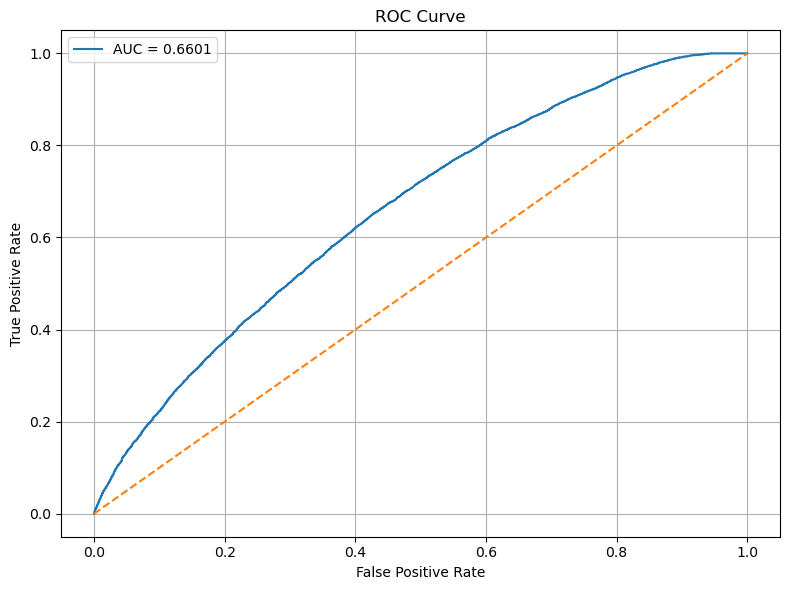

Total time taken: 0h 30m 10.85s
data_max_reg[0] = 99.99932861328125
E_inc=10 GeV: mean error = 0.66, std = 2.27, sat = 0.01%, time = 28.15s
  Bin fraction at true energy: 28.45%
  FWHM: 3.57 GeV
E_inc=20 GeV: mean error = 0.71, std = 3.32, sat = 0.01%, time = 28.65s
  Bin fraction at true energy: 18.56%
  FWHM: 4.76 GeV
E_inc=30 GeV: mean error = 0.53, std = 4.19, sat = 0.01%, time = 120.83s
  Bin fraction at true energy: 15.08%
  FWHM: 7.14 GeV
E_inc=40 GeV: mean error = 0.57, std = 5.02, sat = 0.01%, time = 142.36s
  Bin fraction at true energy: 12.16%
  FWHM: 9.52 GeV
E_inc=50 GeV: mean error = 0.54, std = 5.65, sat = 0.03%, time = 28.24s
  Bin fraction at true energy: 9.85%
  FWHM: 9.52 GeV
E_inc=60 GeV: mean error = 0.33, std = 6.14, sat = 0.09%, time = 28.67s
  Bin fraction at true energy: 9.84%
  FWHM: 8.33 GeV
E_inc=70 GeV: mean error = -0.06, std = 6.66, sat = 0.29%, time = 28.29s
  Bin fraction at true energy: 9.26%
  FWHM: 11.90 GeV
E_inc=80 GeV: mean error = -0.46, std = 7.

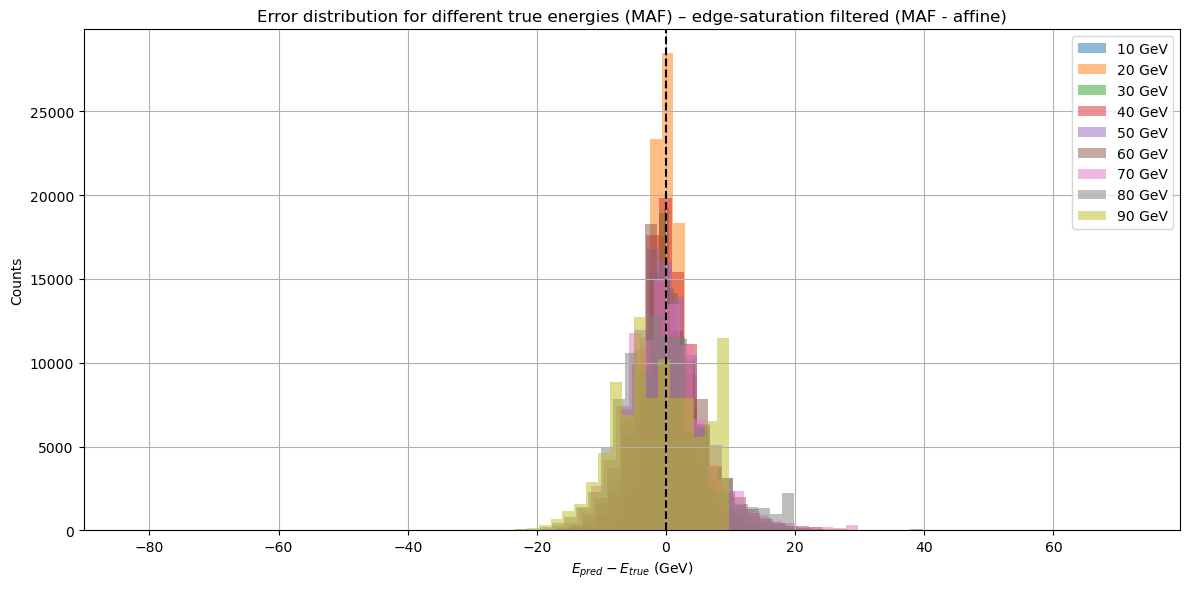

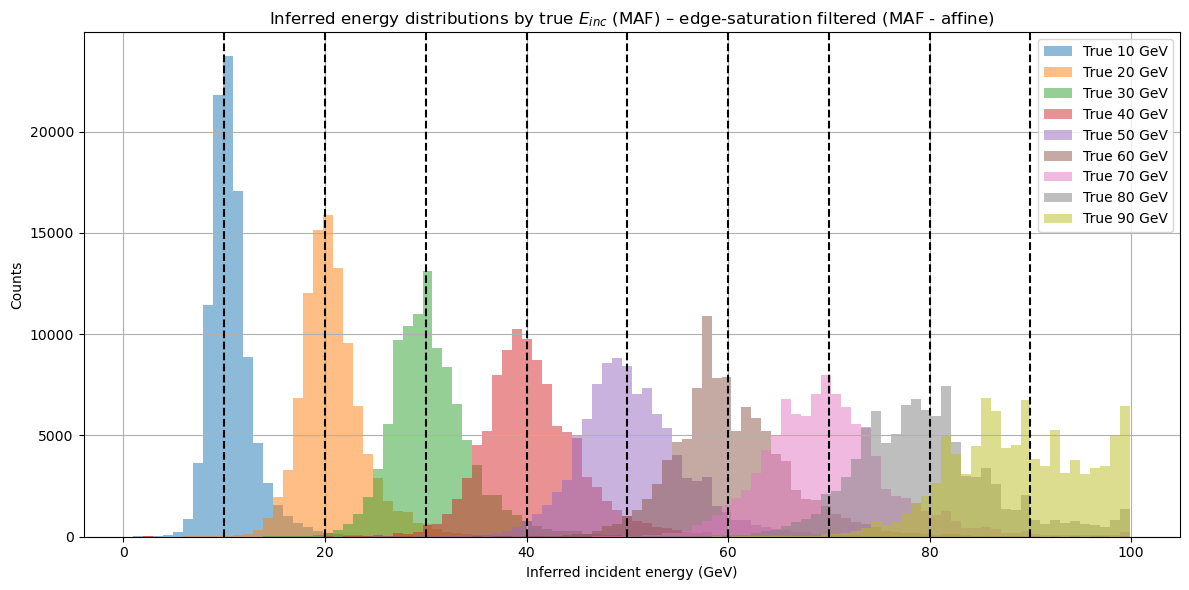


=== Per-energy regression summary (edge-saturation filtered) ===
E_true [GeV]        N   Bias [GeV]  MAE [GeV]  RMSE [GeV]  Std [GeV]  68% width [GeV]  Sat. frac
        10    99994        0.665      1.585       2.370      2.275            3.465      0.01%
        20    99994        0.713      2.366       3.397      3.321            5.247      0.01%
        30    99994        0.529      3.041       4.224      4.191            7.029      0.01%
        40    99993        0.575      3.672       5.056      5.023            8.415      0.01%
        50    99975        0.543      4.149       5.672      5.646            9.702      0.03%
        60    99906        0.330      4.495       6.151      6.142           10.494      0.09%
        70    99713       -0.063      4.879       6.664      6.664           10.989      0.29%
        80    99064       -0.459      5.427       7.171      7.156           12.474      0.94%
        90    97585       -1.134      5.586       6.833      6.738           

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)

def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

def format_elapsed(seconds):
    hours, rem = divmod(seconds, 3600)
    minutes, seconds = divmod(rem, 60)
    return f"{int(hours)}h {int(minutes)}m {seconds:.2f}s"

start_time = time.time()
results_dir = "MAF_affine_results"
os.makedirs(results_dir, exist_ok=True)

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

data = np.hstack((energy.reshape(-1, 1), E_layers))

data[np.isinf(data)] = np.nan
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

if torch.isnan(data_tensor).any() or torch.isinf(data_tensor).any():
    raise ValueError("Data tensor contains NaN or Inf values after transformations.")

mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

train_tensor, val_tensor = train_test_split(
    data_tensor.detach().cpu().numpy(),
    test_size=0.2,
    random_state=42
)
train_tensor = torch.tensor(train_tensor, dtype=torch.float32, device=device)
val_tensor = torch.tensor(val_tensor, dtype=torch.float32, device=device)

context_feature = data_tensor[:, 0].unsqueeze(1)
input_features = data_tensor[:, 1:]

num_layers = 5
base_distribution = StandardNormal(shape=[input_features.shape[1]])
transforms = []

for _ in range(num_layers):
    transforms.append(ReversePermutation(features=input_features.shape[1]))
    transforms.append(MaskedAffineAutoregressiveTransform(
        features=input_features.shape[1],
        hidden_features=64,
        context_features=1
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500
batch_size = 256
best_loss = float('inf')

best_model_path = os.path.join(results_dir, "best_flow_model.pth")
for epoch in range(num_epochs):
    flow.train()

    idx = torch.randperm(len(train_tensor))
    train_tensor = train_tensor[idx]

    train_context = train_tensor[:, 0].unsqueeze(1)
    train_inputs = train_tensor[:, 1:]

    running_train_loss = 0.0
    n_train = 0

    for i in range(0, len(train_inputs), batch_size):
        batch_inputs = train_inputs[i:i + batch_size]
        batch_context = train_context[i:i + batch_size]

        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * batch_inputs.size(0)
            n_train += batch_inputs.size(0)

    flow.eval()
    val_context = val_tensor[:, 0].unsqueeze(1)
    val_inputs = val_tensor[:, 1:]

    running_val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for i in range(0, len(val_inputs), batch_size):
            batch_inputs = val_inputs[i:i + batch_size]
            batch_context = val_context[i:i + batch_size]
            val_loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

            if not torch.isnan(val_loss) and not torch.isinf(val_loss):
                running_val_loss += val_loss.item() * batch_inputs.size(0)
                n_val += batch_inputs.size(0)

    epoch_train_loss = running_train_loss / n_train
    epoch_val_loss = running_val_loss / n_val

    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        torch.save(flow.state_dict(), best_model_path)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss}, Val Loss: {epoch_val_loss}")

flow.load_state_dict(torch.load(best_model_path, map_location=device))
flow.eval()

generative_start_time = time.time()

n_samples = len(data_tensor)
n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen = torch.rand((n_samples,1)).to(device) * 99 + 1
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_context = Einc_gen[i:i+batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)
samples = samples * data_std[1:].cpu() + data_mean[1:].cpu() 
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()

print(f"Final samples shape: {samples.shape}")
print(f"Final data_tensor shape: {data_tensor.shape}")
print(f"Generated {len(samples)} valid samples.")

num_features = data.shape[1] - 1
fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
axs = axs.flatten()

colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features): 
    bins = np.logspace(0, 5, 100)
    ref_color = 'yellow' if i == 0 else colors[i % len(colors)]
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=ref_color,
        density=True,
        log=True
    )
    axs[i].hist(
        samples[:, i],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color='blue',
        density=True,
        log=True
    )
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

for j in range(len(axs)):
    if j >= num_features:
        axs[j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "MAF_affine_reference_vs_generated_histograms.png"), dpi=300, bbox_inches='tight')
plt.show()

generative_end_time = time.time()
generative_elapsed = generative_end_time - generative_start_time

classifier_start_time = time.time()

real_data = data[:, 1:].copy()
generated_data = samples.copy()
generated_data = generated_data[np.isfinite(generated_data).all(axis=1)]

smallest_size = min(len(real_data), len(generated_data))

real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    probs = torch.sigmoid(outputs)
                    preds = torch.round(probs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_scores = []
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            scores = torch.sigmoid(outputs)
            preds = torch.round(scores)
            all_scores.append(scores.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_scores = np.concatenate(all_scores)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_scores)
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc, all_labels, all_scores

train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
}

input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
final_accuracy, final_auc, all_labels_eval, all_scores_eval = evaluate_model(model, dataloaders)

fpr, tpr, _ = roc_curve(all_labels_eval, all_scores_eval)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {final_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "classifier_roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

classifier_end_time = time.time()
classifier_elapsed = classifier_end_time - classifier_start_time

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total time taken: {format_elapsed(elapsed_time)}")

import torch
import h5py
import matplotlib.pyplot as plt

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))

Emin = 1.0
Emax = 120.0
num_scan_points = 1000
batch_size = 10000

errors_by_energy = {}
inferred_by_energy = {}
sat_frac_by_energy = {}

def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg, device):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    data = data[~np.isnan(data).any(axis=1)]

    x = torch.tensor(data, dtype=torch.float32, device=device)
    x = x / data_max_reg
    x = logit_trafo_reg(x)
    x = (x - data_mean_reg) / data_std_reg

    return x[:, 1:]

def infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg, num_scan_points=1000, Emin=1.0, Emax=120.0, batch_size=10000):
    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]

    Emax_eff = float(data_max_reg[0].item()) * 0.999
    E_candidates = torch.linspace(Emin, Emax_eff, num_scan_points, device=device).view(-1, 1)

    E_norm  = E_candidates / data_max_reg[0]
    E_logit = logit_trafo_reg(E_norm)
    E_std   = (E_logit - data_mean_reg[0]) / data_std_reg[0]

    E_context = E_std.view(1, -1, 1).repeat(n_samples, 1, 1)
    inputs    = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)

    flat_inputs  = inputs.view(-1, inputs.shape[-1])
    flat_context = E_context.view(-1, 1)

    log_probs_list = []
    flow.eval()
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            logp = flow.log_prob(flat_inputs[i:i+batch_size], context=flat_context[i:i+batch_size])
            log_probs_list.append(logp)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    max_indices = log_probs.argmax(dim=1)

    inferred_E = E_candidates[max_indices].squeeze(1).cpu().numpy()
    return inferred_E, max_indices.cpu().numpy()

data_mean_reg = data_mean.to(device)
data_std_reg  = data_std.to(device)
data_max_reg  = data_max.to(device)
flow = flow.to(device)

print("data_max_reg[0] =", float(data_max_reg[0].item()))
Emax_eff = float(data_max_reg[0].item()) * 0.999

reg_start_time = time.time()

for E_true in energy_values:
    t0 = time.time()

    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')
    layer_tensor = load_and_preprocess_test_file(
        file_path, data_mean_reg, data_std_reg, data_max_reg, device
    )

    inferred, max_idx = infer_incident_energy(
        flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg,
        num_scan_points=num_scan_points, Emin=Emin, Emax=Emax, batch_size=batch_size
    )

    sat = (max_idx == 0) | (max_idx == (num_scan_points - 1))
    sat_frac = float(sat.mean())
    sat_frac_by_energy[E_true] = sat_frac

    inferred_clean = inferred[~sat]
    if len(inferred_clean) == 0:
        inferred_clean = inferred
        print("  WARNING: all events saturated; keeping unfiltered inferred values for this energy.")

    error = inferred_clean - E_true
    errors_by_energy[E_true] = error
    inferred_by_energy[E_true] = inferred_clean

    print(f"E_inc={E_true} GeV: mean error = {np.mean(error):.2f}, std = {np.std(error):.2f}, "
          f"sat = {sat_frac:.2%}, time = {time.time() - t0:.2f}s")

    counts, bin_edges = np.histogram(inferred_clean, bins=100, range=(Emin, Emax))
    bin_idx = np.digitize([E_true], bin_edges)[0] - 1
    bin_idx = max(0, min(bin_idx, len(counts) - 1))

    ratio_true_bin = counts[bin_idx] / counts.sum() if counts.sum() > 0 else 0.0
    print(f"  Bin fraction at true energy: {ratio_true_bin:.2%}")

    max_count = counts.max() if counts.size > 0 else 0
    half_max = max_count / 2 if max_count > 0 else 0
    above_half = np.where(counts >= half_max)[0] if max_count > 0 else np.array([])

    if len(above_half) > 0:
        fwhm = bin_edges[above_half[-1] + 1] - bin_edges[above_half[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

reg_end_time = time.time()
reg_elapsed = reg_end_time - reg_start_time
print(f"\nTotal regression time: {format_elapsed(reg_elapsed)}")

plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f"{E_true} GeV")
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("$E_{pred} - E_{true}$ (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (MAF) – edge-saturation filtered (MAF - affine)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "regression_error_distributions_MAF_affine.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
for E_true, inferred_clean in inferred_by_energy.items():
    plt.hist(inferred_clean, bins=100, range=(Emin, Emax_eff), alpha=0.5, label=f"True {E_true} GeV")
    plt.axvline(E_true, color='black', linestyle='--')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (MAF) – edge-saturation filtered (MAF - affine)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "regression_inferred_energy_distributions_MAF_affine.png"), dpi=300, bbox_inches='tight')
plt.show()

summary_rows = []

all_errors = []
all_rel_errors = []
total_n = 0

for E_true in energy_values:
    err = np.asarray(errors_by_energy[E_true]).reshape(-1)

    n = len(err)
    total_n += n
    all_errors.append(err)

    rel_err = err / E_true
    all_rel_errors.append(rel_err)

    bias = float(np.mean(err))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    std  = float(np.std(err))

    q16, q50, q84 = np.quantile(err, [0.16, 0.50, 0.84])
    width68 = float(q84 - q16)

    sat = sat_frac_by_energy.get(E_true, np.nan)

    summary_rows.append({
        "E_true [GeV]": E_true,
        "N": n,
        "Bias [GeV]": bias,
        "MAE [GeV]": mae,
        "RMSE [GeV]": rmse,
        "Std [GeV]": std,
        "Median [GeV]": float(q50),
        "68% width [GeV]": width68,
        "Sat. frac": float(sat)
    })

all_errors = np.concatenate(all_errors) if len(all_errors) else np.array([])
all_rel_errors = np.concatenate(all_rel_errors) if len(all_rel_errors) else np.array([])

if len(all_errors) > 0:
    global_bias = float(np.mean(all_errors))
    global_mae  = float(np.mean(np.abs(all_errors)))
    global_rmse = float(np.sqrt(np.mean(all_errors**2)))
    global_std  = float(np.std(all_errors))

    gq16, gq50, gq84 = np.quantile(all_errors, [0.16, 0.50, 0.84])
    global_width68 = float(gq84 - gq16)

    global_rel_mae = float(np.mean(np.abs(all_rel_errors)))
    global_rel_rmse = float(np.sqrt(np.mean(all_rel_errors**2)))
else:
    global_bias = global_mae = global_rmse = global_std = np.nan
    global_width68 = global_rel_mae = global_rel_rmse = np.nan

print("\n=== Per-energy regression summary (edge-saturation filtered) ===")
header = ["E_true [GeV]", "N", "Bias [GeV]", "MAE [GeV]", "RMSE [GeV]", "Std [GeV]", "68% width [GeV]", "Sat. frac"]
print("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>16} {:>10}".format(*header))
for r in summary_rows:
    print("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>16.3f} {:>10.2%}".format(
        r["E_true [GeV]"], r["N"], r["Bias [GeV]"], r["MAE [GeV]"], r["RMSE [GeV]"],
        r["Std [GeV]"], r["68% width [GeV]"], r["Sat. frac"]
    ))

print("\n=== Global regression summary (all energies pooled) ===")
print(f"Total N: {total_n}")
print(f"Bias  [GeV]: {global_bias:.3f}")
print(f"MAE   [GeV]: {global_mae:.3f}")
print(f"RMSE  [GeV]: {global_rmse:.3f}")
print(f"Std   [GeV]: {global_std:.3f}")
print(f"68% width [GeV]: {global_width68:.3f}")
print(f"Relative MAE  [%]: {100*global_rel_mae:.3f}")
print(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}")

results_txt_path = os.path.join(results_dir, "MAF_affine_results.txt")
with open(results_txt_path, "w") as f:
    f.write("MAF - affine results\n")
    f.write("====================\n\n")
    f.write(f"Final Accuracy: {final_accuracy:.6f}\n")
    f.write(f"Final AUC: {final_auc:.6f}\n\n")
    f.write("Timing\n")
    f.write("------\n")
    f.write(f"1. Generative part without classifier: {format_elapsed(generative_elapsed)}\n")
    f.write(f"2. Classifier: {format_elapsed(classifier_elapsed)}\n")
    f.write(f"3. Regression: {format_elapsed(reg_elapsed)}\n")
    f.write(f"Total time taken: {format_elapsed(time.time() - start_time)}\n\n")

    f.write("Per-energy regression summary (edge-saturation filtered)\n")
    f.write("-------------------------------------------------------\n")
    f.write("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>12} {:>16} {:>10}\n".format(
        "E_true", "N", "Bias", "MAE", "RMSE", "Std", "Median", "68% width", "Sat.frac"
    ))
    for r in summary_rows:
        f.write("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>12.3f} {:>16.3f} {:>10.2%}\n".format(
            r["E_true [GeV]"], r["N"], r["Bias [GeV]"], r["MAE [GeV]"], r["RMSE [GeV]"],
            r["Std [GeV]"], r["Median [GeV]"], r["68% width [GeV]"], r["Sat. frac"]
        ))

    f.write("\nGlobal regression summary (all energies pooled)\n")
    f.write("----------------------------------------------\n")
    f.write(f"Total N: {total_n}\n")
    f.write(f"Bias  [GeV]: {global_bias:.3f}\n")
    f.write(f"MAE   [GeV]: {global_mae:.3f}\n")
    f.write(f"RMSE  [GeV]: {global_rmse:.3f}\n")
    f.write(f"Std   [GeV]: {global_std:.3f}\n")
    f.write(f"68% width [GeV]: {global_width68:.3f}\n")
    f.write(f"Relative MAE  [%]: {100*global_rel_mae:.3f}\n")
    f.write(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}\n")